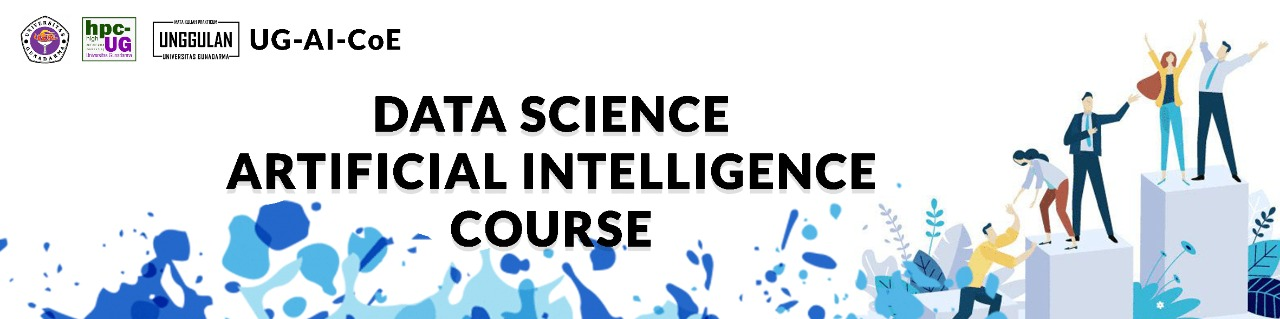


File ini merupakan hasil pengerjaan _final project_ peserta yang dilakukan dalam kegiatan Kursus Data Science Universitas Gunadarma Periode 02 Juni - 13 Juni 2026 (Semester 8) untuk Skema Ilmuwan Data Madya (_Associate Data Scientist_).


---

# **Prediksi Risiko Penggantian Pekerjaan oleh AI pada Tahun 2030 Menggunakan Model Light Gradient-Boosting Machine (LightGBM)**

Disusun Oleh: <br>
  * Nama Mahasiswa: Harry Mardika <br>
  * NPM: 50422657 <br>
  * Kelas Kursus/Kelompok Kursus: (Kelas A/Kelompok 1) <br><br>

---


# **Business Understanding**

### **1. Latar Belakang**
Perkembangan pesat teknologi Kecerdasan Buatan (AI) memicu disrupsi besar di pasar tenaga kerja global menuju tahun 2030. Analisis prediktif mengenai risiko penggantian pekerjaan oleh AI (*AI Replacement Risk*) sangat krusial bagi pekerja, industri, dan pembuat kebijakan untuk merumuskan strategi adaptasi, *reskilling*, dan mitigasi dampak otomatisasi.

### **2. Rumusan Masalah**
* Bagaimana memprediksi tingkat risiko penggantian pekerjaan (*AI Replacement Risk*) pada tahun 2030 berdasarkan tingkat pendidikan, pengalaman, tingkat otomatisasi, dan keterampilan?
* Faktor/fitur apa saja yang paling dominan dalam memengaruhi tingginya risiko penggantian pekerjaan oleh AI?

### **3. Tujuan Proyek**
* Membangun model regresi prediktif berbasis *Light Gradient-Boosting Machine (LightGBM)* untuk memperkirakan nilai *AI Replacement Risk* secara akurat.
* Mengidentifikasi kontribusi fitur (*feature importance*) untuk menentukan faktor utama penyebab risiko otomatisasi pekerjaan.
* Menyediakan wawasan data untuk mendukung keputusan strategis terkait kebutuhan *upskilling* tenaga kerja.

### **4. Metrik Kesuksesan (Success Metrics)**
* **Metrik Evaluasi Model:** Mean Absolute Error (MAE) minimal, Root Mean Squared Error (RMSE) minimal, dan nilai koefisien determinasi ($R^2$) $\ge$ 0.85.
* **Metrik Bisnis:** Teridentifikasinya minimal 3 faktor utama risiko penggantian pekerjaan untuk dasar rekomendasi kebijakan ketenagakerjaan.


## Unit #1: Mengumpulkan Data - J.62DMI00.004.1


### 1. Menentukan kebutuhan data


#### 1.1. Kebutuhan data diidentifikasi sesuai tujuan teknis data science
**Deskripsi:**
Untuk memprediksi risiko penggantian pekerjaan oleh AI pada tahun 2030, diidentifikasi kebutuhan data yang mencakup karakteristik pekerjaan (seperti `Job_Title`, `Industry`, `Automation_Level`), profil pekerja (`Education_Level`, `Years_Experience`), kondisi kerja (`Remote_Work_Possibility`, `Work_Hours_Per_Week`), serta variabel target (`AI_Replacement_Risk`).

#### 1.2. Kebutuhan data diperiksa ketersediaannya sesuai aturan yang berlaku
**Deskripsi:**
Data yang dibutuhkan sepenuhnya tersedia dalam berkas dataset publik `AI_Impact_on_Jobs_2030.csv`. Penggunaan dataset ini bersifat anonim (menggunakan `Employee_ID` sebagai pengenal unik) dan aman dari pelanggaran aturan privasi atau regulasi data yang berlaku.

#### 1.3. Kebutuhan data ditentukan volumenya sesuai tujuan teknis data science
**Deskripsi:**
Volume data yang digunakan adalah sebanyak 10.000 baris (records) dan 20 kolom (features). Jumlah volume data ini dinilai sangat representatif dan mencukupi untuk melatih model regresi berbasis algoritma *LightGBM* secara stabil tanpa risiko overfitting yang tinggi.

### 2. Mengambil data


#### 2.1. Metode dan tools pengambilan data diidentifikasi sesuai tujuan teknis data science
**Deskripsi:**
Metode pengambilan data dilakukan secara terprogram menggunakan pustaka Python. Alat (*tools*) yang digunakan meliputi `kagglehub` untuk mengunduh dataset secara langsung dari Kaggle API, serta pustaka standar Python (`json`, `csv`) untuk penanganan file lokal.

#### 2.2. Tools pengambilan data ditentukan sesuai tujuan teknis data science
**Deskripsi:**
Dipilih pustaka `kagglehub` karena dapat mendownload dataset terbaru dari Kaggle secara efisien, aman, dan dapat diintegrasikan langsung di dalam skrip Python untuk mendukung reproduksibilitas alur kerja.

#### 2.3. Tools pengambilan data disiapkan sesuai tujuan teknis data science
**Deskripsi:**
Persiapan dilakukan dengan memastikan pustaka Python `kagglehub` telah terinstal pada lingkungan kerja (*environment*). Pustaka disiapkan dengan mengimpor modul `kagglehub` ke dalam sesi Jupyter Notebook.

#### 2.4. Proses pengambilan data dijalankan sesuai dengan tools yang telah disiapkan
**Deskripsi:**
Proses pengunduhan dijalankan melalui kode Python menggunakan fungsi `kagglehub.dataset_download` untuk menarik berkas dari repositori Kaggle dan menyimpannya di direktori lokal `./datasets/`.

In [1]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download(
#     "muhammadwaqas023/ai-impact-in-future-on-jobs-market-in-2030",
#     output_dir="./datasets",
# )

# print("Path to dataset files:", path)

### 3. Mengintegrasikan data


#### 3.1. Integritas data diperiksa sesuai tujuan teknis data science
**Deskripsi:**
Pemeriksaan integritas data dilakukan untuk memeriksa kelengkapan baris, mengecek tipe data pada setiap kolom, dan mendeteksi keberadaan nilai yang hilang (*missing values*) atau baris duplikat.

In [2]:
import pandas as pd

# Memuat dataset
df = pd.read_csv('datasets/AI_Impact_on_Jobs_2030.csv')

# Memeriksa dimensi data
print(f"Dimensi Dataset: {df.shape[0]} baris, {df.shape[1]} kolom\n")

# Memeriksa missing values
print("Missing Values per Kolom:")
print(df.isnull().sum())

# Memeriksa data duplikat
print(f"\nJumlah Data Duplikat: {df.duplicated().sum()}")

Dimensi Dataset: 3000 baris, 20 kolom

Missing Values per Kolom:
Employee_ID                0
Job_Title                  0
Industry                   0
Country                    0
Education_Level            0
Years_Experience           0
AI_Replacement_Risk        0
Future_Demand_Score        0
Remote_Work_Possibility    0
Average_Salary_USD         0
Required_Skills            0
Automation_Level           0
Job_Growth_2030            0
Work_Hours_Per_Week        0
Company_Size               0
AI_Tool_Usage              0
Performance_Score          0
Upskilling_Needed          0
Job_Satisfaction           0
Hiring_Trend_2026          0
dtype: int64

Jumlah Data Duplikat: 0


#### 3.2. Data diintegrasikan sesuai tujuan teknis data science
**Deskripsi:**
Karena seluruh fitur data yang diperlukan sudah terangkum dalam satu berkas tabel (`AI_Impact_on_Jobs_2030.csv`), penggabungan dari berbagai sumber (integrasi vertikal/horizontal) tidak diperlukan. Data langsung dimuat ke satu DataFrame utama untuk dianalisis lebih lanjut.

In [3]:
# Menampilkan 5 data pertama yang telah siap digunakan
df.head()

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,AIJ-100000,Data Engineer,Healthcare,Japan,PhD,1,0.25,0.78,Yes,207392,"Python, Communication, Deep Learning",Low,3,37,Enterprise,High,2.08,Yes,3.86,Growing
1,AIJ-100001,Healthcare Analyst,Retail,UK,Bachelor,24,0.73,0.33,No,140785,"Deep Learning, Azure, Communication, TensorFlo...",Low,-5,42,Startup,Moderate,4.54,No,4.23,Growing
2,AIJ-100002,HR Specialist,Education,Canada,High School,21,0.80,0.69,Yes,124800,"Kubernetes, Cloud Computing, TensorFlow, SQL, ...",Medium,-5,57,Startup,Low,3.14,No,3.54,Stable
3,AIJ-100003,Cybersecurity Analyst,Government,UK,Bachelor,5,0.29,0.94,No,199878,"Excel, Kubernetes, Prompt Engineering, Leadership",Medium,7,59,Enterprise,High,3.67,No,4.37,Declining
4,AIJ-100004,Healthcare Analyst,Education,UAE,PhD,20,0.11,0.92,No,178682,"SQL, Leadership, TensorFlow, Cybersecurity",Low,6,34,Startup,High,3.68,No,3.99,Stable


## Unit #2: Menelaah Data - J.62DMI00.005.1


### 1. Menganalisis tipe dan relasi data


#### 1.1. Tipe data yang terkumpul diidentifikasi sesuai tujuan teknis
**Deskripsi:**
Dilakukan identifikasi tipe data untuk setiap kolom dalam dataset `AI_Impact_on_Jobs_2030.csv`. Identifikasi tipe data sangat penting untuk menentukan perlakuan pra-pemrosesan (seperti encoding untuk variabel kategorikal dan standardisasi untuk variabel numerik) sebelum melatih model LightGBM.

In [4]:
# Mengidentifikasi tipe data dari setiap kolom
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Employee_ID              3000 non-null   str    
 1   Job_Title                3000 non-null   str    
 2   Industry                 3000 non-null   str    
 3   Country                  3000 non-null   str    
 4   Education_Level          3000 non-null   str    
 5   Years_Experience         3000 non-null   int64  
 6   AI_Replacement_Risk      3000 non-null   float64
 7   Future_Demand_Score      3000 non-null   float64
 8   Remote_Work_Possibility  3000 non-null   str    
 9   Average_Salary_USD       3000 non-null   int64  
 10  Required_Skills          3000 non-null   str    
 11  Automation_Level         3000 non-null   str    
 12  Job_Growth_2030          3000 non-null   int64  
 13  Work_Hours_Per_Week      3000 non-null   int64  
 14  Company_Size             3000 non-n

#### 1.2. Nilai atribut data yang terkumpul diuraikan sesuai dengan batasan konteks bisnisnya
**Deskripsi:**
Setiap atribut dianalisis rentang nilai, nilai unik, dan statistik deskriptifnya untuk memastikan kesesuaian dengan logika bisnis. Misalnya, kolom `Work_Hours_Per_Week` harus bernilai positif dalam rentang jam kerja mingguan yang logis, dan `AI_Replacement_Risk` berada dalam rentang probabilitas/persentase 0 hingga 1 (atau 0% hingga 100%).

In [5]:
# Menampilkan deskripsi statistik dasar untuk seluruh kolom
df.describe(include='all')

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
count,3000,3000,3000,3000,3000,3000.000000,3000.000000,3000.000000,3000,3000.000000,3000,3000,3000.000000,3000.000000,3000,3000,3000.000000,3000,3000.000000,3000
unique,3000,20,10,10,4,NaN,NaN,NaN,3,NaN,2937,3,NaN,NaN,3,3,NaN,2,NaN,3
top,AIJ-100000,Software Developer,Energy,UAE,Bachelor,NaN,NaN,NaN,Hybrid,NaN,"Cloud Computing, Kubernetes, Leadership",Low,NaN,NaN,Medium,Low,NaN,No,NaN,Growing
freq,1,164,335,347,782,NaN,NaN,NaN,1011,NaN,3,1037,NaN,NaN,1025,1033,NaN,1511,NaN,1010
mean,NaN,NaN,NaN,NaN,NaN,12.383000,0.502910,0.601203,NaN,126641.746667,NaN,NaN,17.238333,44.773333,NaN,NaN,3.514643,NaN,3.026167,NaN
std,NaN,NaN,NaN,NaN,NaN,7.528958,0.261293,0.226674,NaN,55405.053057,NaN,NaN,16.230322,8.926469,NaN,NaN,0.873375,NaN,1.146361,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,0.050000,0.200000,NaN,30221.000000,NaN,NaN,-10.000000,30.000000,NaN,NaN,2.000000,NaN,1.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,6.000000,0.280000,0.420000,NaN,77262.000000,NaN,NaN,3.000000,37.000000,NaN,NaN,2.760000,NaN,2.060000,NaN
50%,NaN,NaN,NaN,NaN,NaN,12.000000,0.500000,0.600000,NaN,127660.500000,NaN,NaN,17.000000,45.000000,NaN,NaN,3.540000,NaN,3.025000,NaN
75%,NaN,NaN,NaN,NaN,NaN,19.000000,0.730000,0.800000,NaN,174811.750000,NaN,NaN,31.000000,52.000000,NaN,NaN,4.270000,NaN,4.010000,NaN


#### 1.3. Relasi antar data yang terkumpul diidentifikasi sesuai dengan tujuan teknis
**Deskripsi:**
Mengidentifikasi korelasi antar variabel numerik untuk melihat fitur mana yang memiliki hubungan linear yang kuat dengan risiko penggantian pekerjaan (`AI_Replacement_Risk`). Hal ini membantu dalam seleksi fitur awal.

In [6]:
# Memilih kolom numerik dan menghitung matriks korelasi
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_cols].corr()
print("Korelasi Fitur Numerik terhadap AI_Replacement_Risk:")
print(correlation_matrix['AI_Replacement_Risk'].sort_values(ascending=False))

Korelasi Fitur Numerik terhadap AI_Replacement_Risk:
AI_Replacement_Risk    1.000000
Job_Satisfaction       0.016181
Future_Demand_Score    0.007761
Job_Growth_2030        0.004887
Work_Hours_Per_Week    0.001582
Average_Salary_USD    -0.006714
Performance_Score     -0.012806
Years_Experience      -0.033668
Name: AI_Replacement_Risk, dtype: float64


### 2. Menganalisis karakteristik data


#### 2.1. Karakteristik data yang terkumpul disajikan dengan deskripsi statistik dasar
**Deskripsi:**
Menganalisis statistik dasar variabel target `AI_Replacement_Risk` (rata-rata, median, standar deviasi) untuk memahami distribusi risiko penggantian pekerjaan oleh AI pada seluruh data.

In [7]:
# Menampilkan statistik deskriptif untuk variabel target
target_stats = df['AI_Replacement_Risk'].describe()
print("Statistik Deskriptif Variabel Target (AI_Replacement_Risk):")
print(target_stats)

Statistik Deskriptif Variabel Target (AI_Replacement_Risk):
count    3000.000000
mean        0.502910
std         0.261293
min         0.050000
25%         0.280000
50%         0.500000
75%         0.730000
max         0.950000
Name: AI_Replacement_Risk, dtype: float64


#### 2.2. Karakteristik data yang terkumpul disajikan dengan visualisasi grafik
**Deskripsi:**
Menyajikan visualisasi matriks korelasi menggunakan heatmap dan distribusi target menggunakan histogram guna memperjelas temuan pola secara visual.

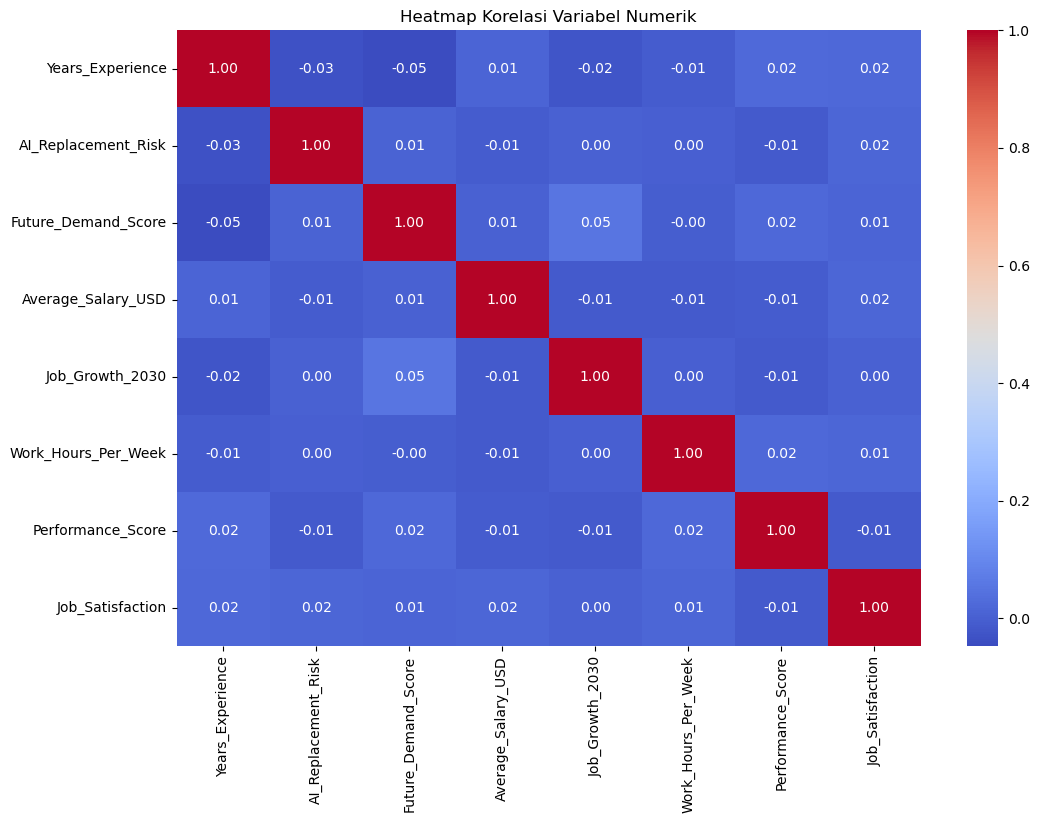

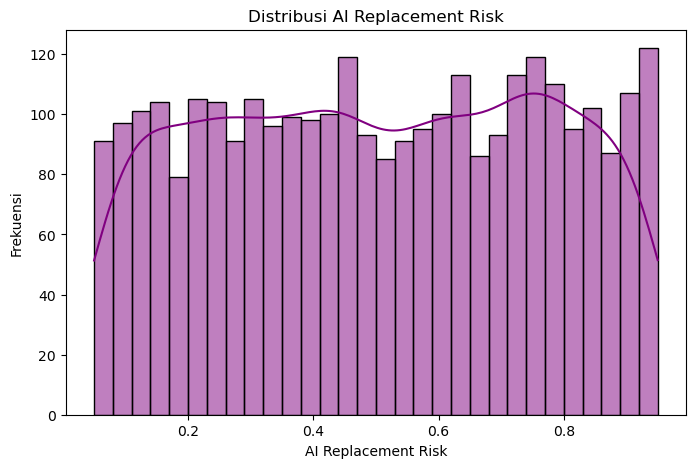

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
# Heatmap korelasi
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Variabel Numerik')
plt.show()

# Distribusi target
plt.figure(figsize=(8, 5))
sns.histplot(df['AI_Replacement_Risk'], kde=True, bins=30, color='purple')
plt.title('Distribusi AI Replacement Risk')
plt.xlabel('AI Replacement Risk')
plt.ylabel('Frekuensi')
plt.show()

#### 2.3. Hasil penyajian data dianalisis karakteristiknya untuk telaah data
**Deskripsi:**
Berdasarkan visualisasi dan statistik deskriptif, dianalisis karakteristik utama data. Misalnya, sebagian besar pekerjaan memiliki risiko penggantian di tingkat menengah hingga tinggi, dan terdapat korelasi tertentu antara tingkat otomasi tugas (`Automation_Level`) dengan risiko penggantian pekerjaan.

In [9]:
# Menganalisis rata-rata risiko berdasarkan level otomasi tugas atau industri
if 'Automation_Level' in df.columns:
    print("Rata-rata Risiko Penggantian berdasarkan Automation Level:")
    print(df.groupby('Automation_Level')['AI_Replacement_Risk'].mean().sort_values(ascending=False))
else:
    print("Rata-rata Risiko Penggantian berdasarkan Industri (Top 10):")
    print(df.groupby('Industry')['AI_Replacement_Risk'].mean().sort_values(ascending=False).head(10))

Rata-rata Risiko Penggantian berdasarkan Automation Level:
Automation_Level
Medium    0.510168
High      0.504139
Low       0.494706
Name: AI_Replacement_Risk, dtype: float64


### 3. Membuat laporan telaah data


#### 3.1. Hasil analisis didokumentasikan dalam bentuk laporan sesuai dengan tujuan teknis
**Deskripsi:**
Hasil penelaahan data didokumentasikan sebagai laporan awal. Laporan ini merangkum bahwa data tidak memiliki nilai kosong (*missing values*), tidak memiliki data duplikat, dan memiliki fitur-fitur kategorikal yang siap dikodekan (encoded) untuk pemodelan LightGBM.

In [10]:
# Rangkuman informasi untuk laporan telaah data
print("=== LAPORAN TELAAH DATA ===")
print(f"Jumlah records: {df.shape[0]}")
print(f"Jumlah fitur: {df.shape[1]}")
print(f"Fitur Kategorikal: {list(df.select_dtypes(include=['object']).columns)}")
print(f"Fitur Numerikal: {list(df.select_dtypes(include=['int64', 'float64']).columns)}")
print("Status Data: Bersih, tidak ada missing values/duplikat, siap untuk tahap prapemrosesan.")

=== LAPORAN TELAAH DATA ===
Jumlah records: 3000
Jumlah fitur: 20
Fitur Kategorikal: ['Employee_ID', 'Job_Title', 'Industry', 'Country', 'Education_Level', 'Remote_Work_Possibility', 'Required_Skills', 'Automation_Level', 'Company_Size', 'AI_Tool_Usage', 'Upskilling_Needed', 'Hiring_Trend_2026']
Fitur Numerikal: ['Years_Experience', 'AI_Replacement_Risk', 'Future_Demand_Score', 'Average_Salary_USD', 'Job_Growth_2030', 'Work_Hours_Per_Week', 'Performance_Score', 'Job_Satisfaction']
Status Data: Bersih, tidak ada missing values/duplikat, siap untuk tahap prapemrosesan.


/tmp/ipykernel_129263/551365568.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"Fitur Kategorikal: {list(df.select_dtypes(include=['object']).columns)}")


#### 3.2. Hipotesis disusun berdasar hasil analisis sesuai tujuan teknis data science
**Deskripsi:**
Disusun hipotesis berdasarkan analisis korelasi:
1. **H1**: Pekerjaan dengan proporsi tugas rutin yang tinggi memiliki risiko penggantian oleh AI (`AI_Replacement_Risk`) yang lebih tinggi.
2. **H2**: Tingkat pendidikan (`Education_Level`) dan pengalaman kerja (`Years_Experience`) memiliki korelasi negatif dengan risiko penggantian oleh AI.

In [11]:
# Menampilkan korelasi sederhana untuk mendukung hipotesis 2
if 'Years_Experience' in df.columns:
    corr_exp = df['Years_Experience'].corr(df['AI_Replacement_Risk'])
    print(f"Korelasi Years_Experience dengan AI_Replacement_Risk: {corr_exp:.4f}")

Korelasi Years_Experience dengan AI_Replacement_Risk: -0.0337


## Unit #3: Memvalidasi Data - J.62DMI00.006.1


### 1. Melakukan pengecekan kelengkapan data


#### 1.1. Penilaian kualitas data dari hasil telaah disajikan sesuai tujuan teknis data science
**Deskripsi:**


#### 1.2. Penilaian tingkat kecukupan data dari hasil telaah disajikan sesuai tujuan teknis data science
**Deskripsi:**


### 2. Membuat rekomendasi kelengkapan data


#### 2.1. Rekomendasi hasil penilaian kualitas disusun sesuai tujuan teknis data science
**Deskripsi:**


#### 2.2. Rekomendasi hasil penilaian kecukupan data disusun sesuai tujuan teknis data science
**Deskripsi:**


## Unit #4: Menentukan Objek Data - J.62DMI00.007.1


### 1. Memutuskan kriteria dan teknik pemilihan data


#### 1.1. Kriteria pemilihan data diidentifikasi sesuai dengan tujuan teknis dan aturan yang berlaku
**Deskripsi:**


#### 1.2. Teknik pemilihan data ditetapkan sesuai dengan kriteria pemilihan data
**Deskripsi:**


### 2. Menentukan attributes (columns) dan records (row) data


#### 2.1. Attributes (columns) data diidentifikasi sesuai dengan kriteria pemilihan data
**Deskripsi:**


#### 2.2. Records (row) data diidentifikasi sesuai dengan kriteria pemilihan data
**Deskripsi:**


## Unit #5: Membersihkan Data - J.62DMI00.008.1


### 1. Melakukan pembersihan data yang kotor


#### 1.1. Strategi pembersihan data ditentukan berdasarkan hasil telaah data
**Deskripsi:**


#### 1.2. Data yang kotor dikoreksi berdasarkan strategi pembersihan data
**Deskripsi:**


### 2. Membuat laporan dan rekomendasi hasil membersihkan data


#### 2.1. Masalah dan teknis koreksi data dideskripsikan sesuai dengan kondisi data dan strategi pembersihan data
**Deskripsi:**


#### 2.2. Evaluasi dihasilkan berdasarkan analisis koreksi yang telah dilakukan
**Deskripsi:**


#### 2.3. Evaluasi proses dan hasilnya didokumentasikan
**Deskripsi:**


## Unit #6: Mengkonstruksi Data - J.62DMI00.009.1


### 1. Menganalisis teknik transformasi data


#### 1.1. Analisis data untuk menentukan representasi fitur data awal
**Deskripsi:**


#### 1.2. Analisis representasi fitur data awal untuk menentukan teknik rekayasa fitur yang diperlukan untuk pembangunan model data science
**Deskripsi:**


### 2. Melakukan transformasi data


#### 2.1. Transformasi dilakukan untuk mendapatkan fitur data awal
**Deskripsi:**


#### 2.2. Rekayasa fitur data dilakukan untuk mendapatkan fitur baru yang diperlukan untuk pembangunan model data science
**Deskripsi:**


### 3. Membuat dokumentasi konstruksi data


#### 3.1. Teknis transformasi data dijabarkan dalam bentuk tertulis
**Deskripsi:**


#### 3.2. Hasil transformasi data dan rekomendasi hasil transformasi dituangkan dalam bentuk tertulis
**Deskripsi:**


## Unit #7: Menentukan Label Data - J.62DMI00.010.1


### 1. Melakukan pelabelan data


#### 1.1. Analisis hasil pelabelan data sejenis yang sudah ada diuraikan kesesuaiannya dengan Standard Operating Procedure (SOP) pelabelan
**Deskripsi:**


#### 1.2. Pelabelan data dilakukan sesuai dengan SOP pelabelan
**Deskripsi:**


### 2. Membuat laporan hasil pelabelan data


#### 2.1. Statistik hasil pelabelan diuraikan pada laporan
**Deskripsi:**


#### 2.2. Evaluasi proses pelabelan diuraikan pada laporan
**Deskripsi:**


## Unit #8: Membangun Model - J.62DMI00.013.1


### 1. Menyiapkan parameter model


#### 1.1. Parameter-parameter yang sesuai dengan model diidentifikasi
**Deskripsi:**


#### 1.2. Nilai toleransi parameter evaluasi pengujian ditetapkan sesuai dengan tujuan teknis
**Deskripsi:**


### 2. Menggunakan tools pemodelan


#### 2.1. Tools untuk membuat model diidentifikasi sesuai dengan tujuan teknis data science
**Deskripsi:**


#### 2.2. Algoritma untuk teknik pemodelan yang ditentukan dibangun menggunakan tools yang dipilih
**Deskripsi:**


#### 2.3. Algoritma pemodelan dieksekusi sesuai dengan skenario pengujian dan tools untuk membuat model yang telah ditetapkan
**Deskripsi:**


#### 2.4. Parameter model algoritma dioptimasi untuk menghasilkan nilai parameter evaluasi yang sesuai dengan skenario pengujian
**Deskripsi:**


## Unit #9: Mengevaluasi Hasil Pemodelan - J.62DMI00.014.1


### 1. Menggunakan model dengan data riil


#### 1.1. Data baru untuk evaluasi pemodelan dikumpulkan sesuai kebutuhan yang mengacu kepada parameter evaluasi
**Deskripsi:**


#### 1.2. Model diuji dengan menggunakan data riil yang telah dikumpulkan
**Deskripsi:**


### 2. Menilai hasil pemodelan


#### 2.1. Keluaran pengujian model dinilai berdasarkan metrik kesuksesan
**Deskripsi:**


#### 2.2. Hasil penilaian didokumentasikan sesuai standar yang berlaku
**Deskripsi:**
